<a href="https://colab.research.google.com/github/IrineuBovoJunior398/P-S_GRADUA-O_IA_UTFPR/blob/main/C%C3%B3pia_de_CODIGO_PRATICO_PERCEPTRON_OU_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Resultados do Perceptron:
Acurácia: 0.6333333333333333
Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.45      1.00      0.62         9
   virginica       0.00      0.00      0.00        11

    accuracy                           0.63        30
   macro avg       0.48      0.67      0.54        30
weighted avg       0.47      0.63      0.52        30

Matriz de Confusão:
[[10  0  0]
 [ 0  9  0]
 [ 0 11  0]]

Resultados do MLPClassifier:
Acurácia: 0.9333333333333333
Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.89      0.89         9
   virginica       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Matriz de C

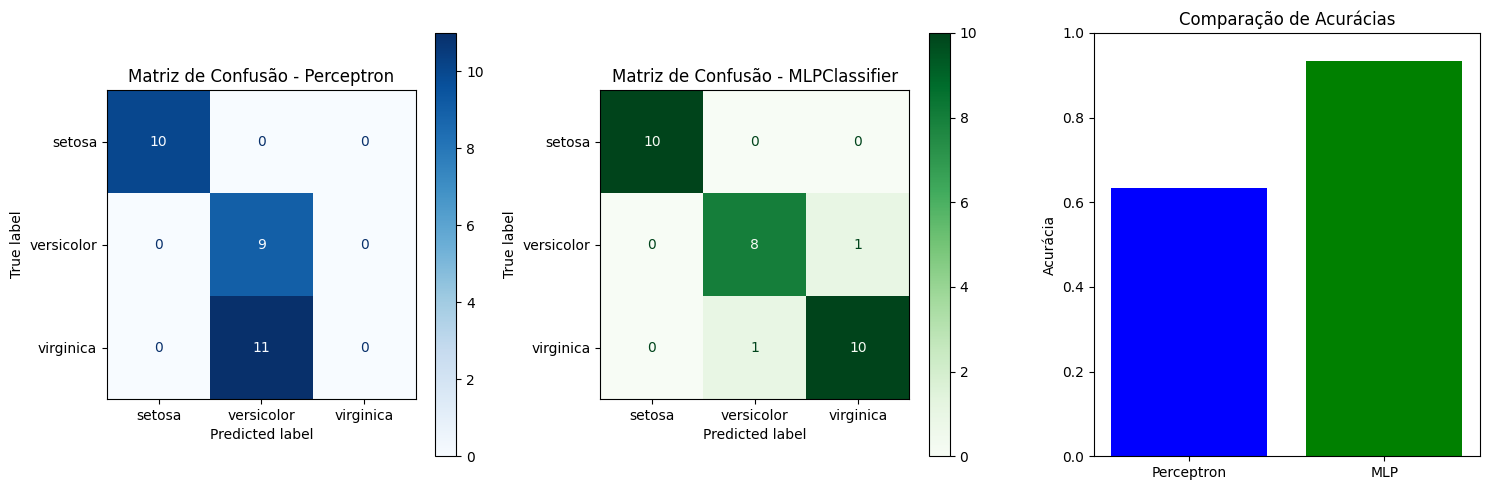

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Carregar o dataset Iris
data = load_iris()
X = data.data
y = data.target

# Dividir em treino (80%) e teste (20%) com random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar Perceptron
perceptron = Perceptron(random_state=42)
perceptron.fit(X_train, y_train)

# Treinar MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

# Fazer predições no teste
y_pred_perceptron = perceptron.predict(X_test)
y_pred_mlp = mlp.predict(X_test)

# Calcular métricas para Perceptron
acc_perceptron = accuracy_score(y_test, y_pred_perceptron)
report_perceptron = classification_report(y_test, y_pred_perceptron, target_names=data.target_names)
cm_perceptron = confusion_matrix(y_test, y_pred_perceptron)

# Calcular métricas para MLP
acc_mlp = accuracy_score(y_test, y_pred_mlp)
report_mlp = classification_report(y_test, y_pred_mlp, target_names=data.target_names)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

# Imprimir resultados
print("Resultados do Perceptron:")
print(f"Acurácia: {acc_perceptron}")
print("Relatório de Classificação:")
print(report_perceptron)
print("Matriz de Confusão:")
print(cm_perceptron)
print()

print("Resultados do MLPClassifier:")
print(f"Acurácia: {acc_mlp}")
print("Relatório de Classificação:")
print(report_mlp)
print("Matriz de Confusão:")
print(cm_mlp)
print()

# Comparar erros: valor predito (previsão do modelo) vs valor esperado (rótulo verdadeiro)
print("Exemplos de Comparação de Erros (Perceptron):")
for i in range(5):
    # Valor predito: previsão do modelo
    pred = y_pred_perceptron[i]
    # Valor esperado: rótulo verdadeiro
    expected = y_test[i]
    print(f"Exemplo {i+1}: Predito = {data.target_names[pred]}, Esperado = {data.target_names[expected]}")
print()

print("Exemplos de Comparação de Erros (MLP):")
for i in range(5):
    pred = y_pred_mlp[i]
    expected = y_test[i]
    print(f"Exemplo {i+1}: Predito = {data.target_names[pred]}, Esperado = {data.target_names[expected]}")
print()

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Matriz de confusão Perceptron
ConfusionMatrixDisplay(cm_perceptron, display_labels=data.target_names).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Matriz de Confusão - Perceptron')

# Matriz de confusão MLP
ConfusionMatrixDisplay(cm_mlp, display_labels=data.target_names).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Matriz de Confusão - MLPClassifier')

# Gráfico de barras comparando acurácias
models = ['Perceptron', 'MLP']
accuracies = [acc_perceptron, acc_mlp]
axes[2].bar(models, accuracies, color=['blue', 'green'])
axes[2].set_title('Comparação de Acurácias')
axes[2].set_ylabel('Acurácia')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()